In [9]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from config import ModelConfig
from membraneReactorModel import MembraneReactorModel


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
cfg = ModelConfig()
model = MembraneReactorModel(cfg)

result = model.solve()

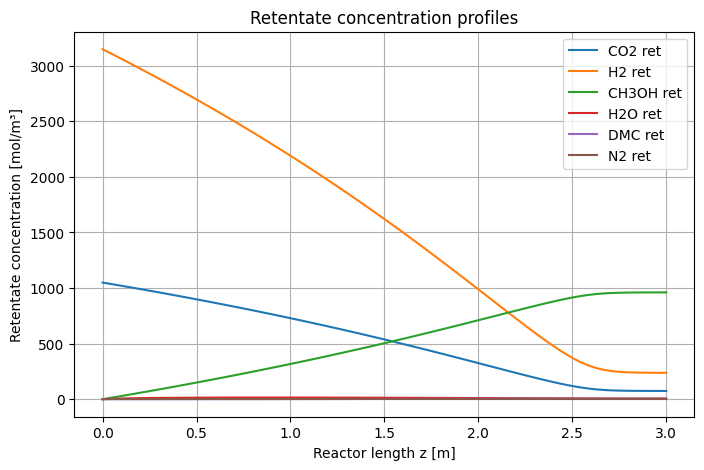

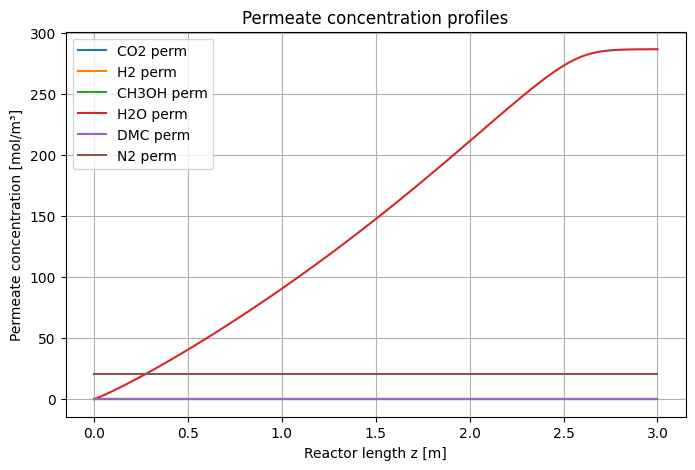

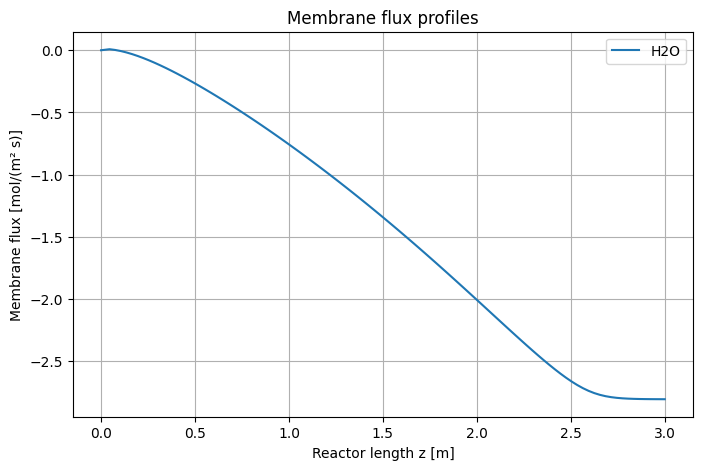

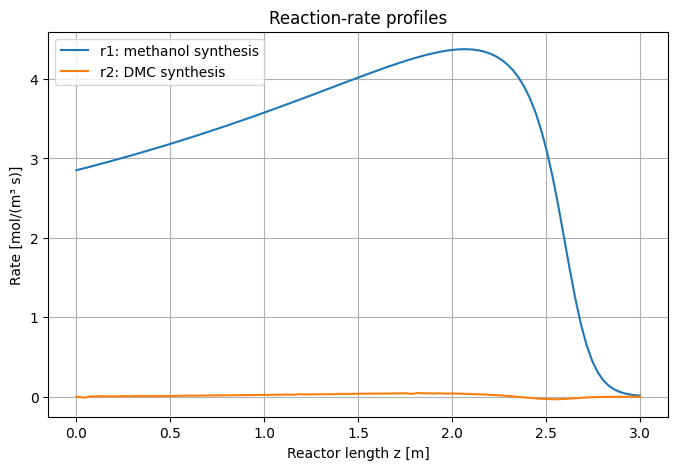

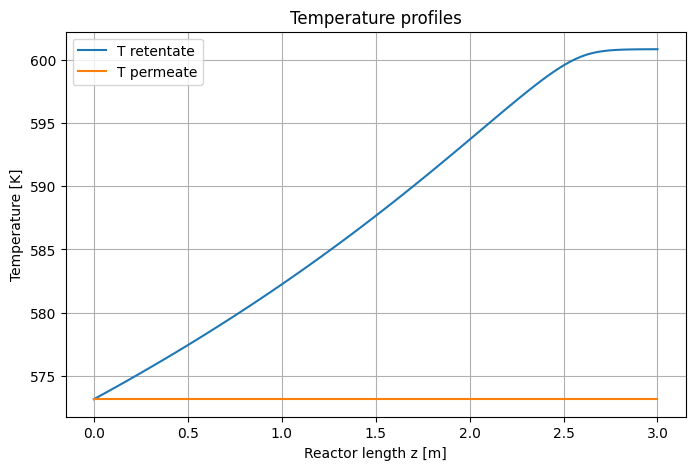

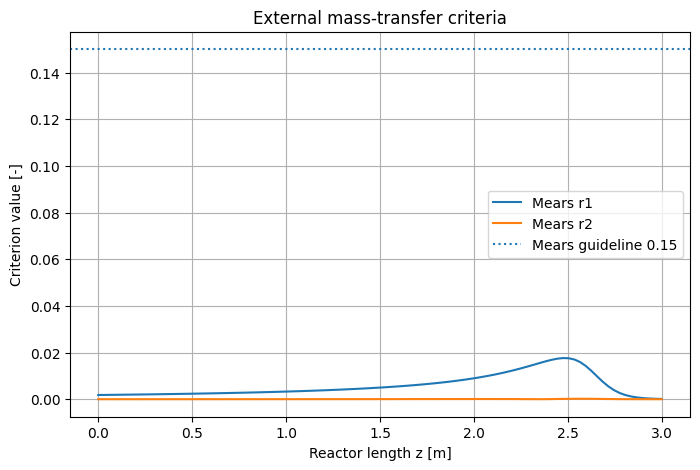

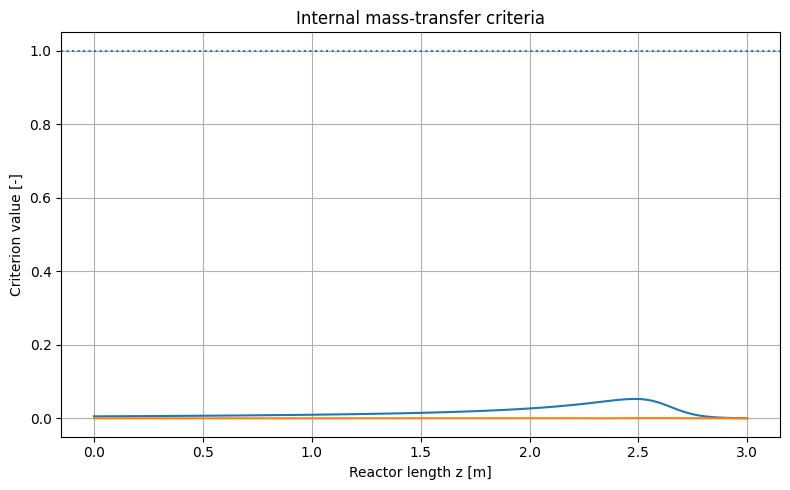

In [11]:
c_ret, T_ret, c_perm, T_perm = model.fields()
z = model.z_c
species = list(model.species_labels)
n_species = cfg.n_species

r1, r2 = model.reac.reaction_rates(c_ret, T_ret)
source = model.reac.species_source(c_ret, T_ret)
r_CO2_consumption = -source[:, 0]

P_species = np.asarray(cfg.P_species, dtype=float)
J_mem = P_species[None, :] * (c_ret - c_perm)  # [mol/(m2 s)]

c_in = cfg.inlet_concentration

D_eff_CO2 = cfg.eps_p * cfg.particle_diffusivity[0] / cfg.tortuosity

# Mears criterion:
mears_r1, mears_r2 = model.mears_criterion()
wp_r1, wp_r2 = model.weisz_prater_criterion()


# 1. Retentate concentrations
plt.figure(figsize=(8,5))
for i, name in enumerate(species):
    plt.plot(z, c_ret[:, i], label=f"{name} ret")
plt.xlabel("Reactor length z [m]")
plt.ylabel("Retentate concentration [mol/m³]")
plt.title("Retentate concentration profiles")
plt.grid(True)
plt.legend()

# 2. Permeate concentrations
plt.figure(figsize=(8,5))
for i, name in enumerate(species):
    plt.plot(z, c_perm[:, i], label=f"{name} perm")
plt.xlabel("Reactor length z [m]")
plt.ylabel("Permeate concentration [mol/m³]")
plt.title("Permeate concentration profiles")
plt.grid(True)
plt.legend()

# 3. Membrane flux
plt.figure(figsize=(8,5))
for i, name in enumerate(species):
    if np.any(np.abs(J_mem[:, i]) > 1e-20):
        plt.plot(z, J_mem[:, i], label=f"{name}")
plt.xlabel("Reactor length z [m]")
plt.ylabel("Membrane flux [mol/(m² s)]")
plt.title("Membrane flux profiles")
plt.grid(True)
plt.legend()

# 4. Reaction rates
plt.figure(figsize=(8,5))
plt.plot(z, r1, label="r1: methanol synthesis")
plt.plot(z, r2, label="r2: DMC synthesis")
plt.xlabel("Reactor length z [m]")
plt.ylabel("Rate [mol/(m³ s)]")
plt.title("Reaction-rate profiles")
plt.grid(True)
plt.legend()

# 5. Temperature profile
plt.figure(figsize=(8,5))
plt.plot(z, T_ret, label="T retentate")
plt.plot(z, T_perm, label="T permeate")
plt.xlabel("Reactor length z [m]")
plt.ylabel("Temperature [K]")
plt.title("Temperature profiles")
plt.grid(True)
plt.legend()

# 6. Criteria and conversions
plt.figure(figsize=(8,5))
plt.plot(z, mears_r1, label="Mears r1")
plt.plot(z, mears_r2, label="Mears r2")
plt.axhline(0.15, linestyle=":", label="Mears guideline 0.15")
plt.xlabel("Reactor length z [m]")
plt.ylabel("Criterion value [-]")
plt.title("External mass-transfer criteria")
plt.grid(True)
plt.legend()

plt.figure(figsize=(8,5))
plt.plot(z, wp_r1, label="Weisz-Prater r1")
plt.plot(z, wp_r2, label="Weisz-Prater r2")
plt.axhline(1, linestyle=":", label="WP guideline 1")
plt.xlabel("Reactor length z [m]")
plt.ylabel("Criterion value [-]")
plt.title("Internal mass-transfer criteria")
plt.grid(True)
plt.tight_layout()
plt.show()


In [12]:
concentration_table = pd.DataFrame({
    "inlet retentate [mol/m3]": c_in,
    "outlet retentate [mol/m3]": c_ret[-1, :],
    "outlet permeate [mol/m3]": c_perm[-1, :],
    "retentate change [mol/m3]": c_ret[-1, :] - c_in,
}, index=species)

print("\n=== COMPONENT CONCENTRATIONS ===")
print(concentration_table.to_string())


=== COMPONENT CONCENTRATIONS ===
       inlet retentate [mol/m3]  outlet retentate [mol/m3]  outlet permeate [mol/m3]  retentate change [mol/m3]
CO2                 1049.280707                  74.447597                  0.000000                -974.833110
H2                  3147.842120                 237.424702                  0.000000               -2910.417418
CH3OH                  0.000000                 960.751199                  0.000000                 960.751199
H2O                    0.000000                   6.271569                286.981197                   6.271569
DMC                    0.000000                   4.693970                  0.000000                   4.693970
N2                     0.000000                   0.000000                 20.985614                   0.000000


In [14]:
print("pressure drop", cfg.ergun_pressure_gradient)

ValueError: operands could not be broadcast together with shapes (5,) (6,) 